In [ ]:
# Section 1: Import Libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
from torchvision.models import mobilenet_v2
import torch.nn.functional as F
from torchvision.transforms import Resize
from sklearn.cluster import KMeans


In [ ]:
# Section 2: Helper Functions
def adaptive_mix(x_real, x_fake, alpha=1.0):
    lambda_val = torch.distributions.Beta(alpha, alpha).sample().to(x_real.device)
    mixed_x = lambda_val * x_real + (1 - lambda_val) * x_fake
    return mixed_x

class Generator(nn.Module):
    def __init__(self, z_dim, img_channels):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, img_channels * 32 * 32),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z).view(-1, 3, 32, 32)

class Discriminator(nn.Module):
    def __init__(self, img_channels):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(img_channels * 32 * 32, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

def get_dataloader(batch_size=128):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    dataset = torchvision.datasets.CIFAR10(root="./data", train=True, transform=transform, download=True)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)

def inception_score(images, device, num_splits=10):
    model = mobilenet_v2(weights="MobileNet_V2_Weights.IMAGENET1K_V1").to(device)
    model.classifier = nn.Identity()
    model.eval()

    resize = Resize((64, 64))  # Resize to fit MobileNetV2

    scores = []
    with torch.no_grad():
        for i in range(num_splits):
            batch = images[i::num_splits].to(device)
            batch = resize(batch)
            preds = model(batch)
            preds = F.softmax(preds, dim=1).cpu().numpy()
            kl_div = preds * (np.log(preds) - np.log(np.expand_dims(preds.mean(axis=0), 0)))
            scores.append(np.exp(kl_div.sum(axis=1).mean()))

    return np.mean(scores), np.std(scores)

def cluster_images(images, n_clusters=4):
    """
    Clusters the images using k-means and returns the centroids of the clusters.
    """
    # Flatten the images into a 2D array (batch_size, img_size)
    batch_size = images.size(0)
    img_size = images.size(1) * images.size(2) * images.size(3)
    images_flat = images.view(batch_size, -1).cpu().numpy()

    # Apply k-means clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(images_flat)
    cluster_centroids = kmeans.cluster_centers_

    # Get the indices of the images closest to the centroids
    closest_indices = []
    for center in cluster_centroids:
        distances = np.linalg.norm(images_flat - center, axis=1)
        closest_indices.append(np.argmin(distances))

    # Return the images corresponding to the closest centroids
    return images[closest_indices]


In [ ]:
# Section 3: Train GAN with Clustering
def train_gan_with_clustering(epochs=50, batch_size=128, alpha=1.0, z_dim=100, n_clusters=4):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    dataloader = get_dataloader(batch_size)
    img_channels = 3

    generator = Generator(z_dim, img_channels).to(device)
    discriminator = Discriminator(img_channels).to(device)

    criterion = nn.BCELoss()
    optimizer_g = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
    optimizer_d = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

    real_label, fake_label = 1, 0

    loss_g_list, loss_d_list = [], []
    is_list = []  # Define is_list here to store Inception Scores

    for epoch in range(epochs):
        for real_images, _ in dataloader:
            real_images = real_images.to(device)
            batch_size = real_images.size(0)

            z = torch.randn(batch_size, z_dim).to(device)
            fake_images = generator(z)

            mixed_images = adaptive_mix(real_images, fake_images, alpha)

            optimizer_d.zero_grad()
            real_output = discriminator(real_images)
            fake_output = discriminator(fake_images.detach())

            loss_d_real = criterion(real_output, torch.ones_like(real_output) * 0.9)
            loss_d_fake = criterion(fake_output, torch.zeros_like(fake_output))
            loss_d = (loss_d_real + loss_d_fake) / 2
            loss_d.backward()
            optimizer_d.step()

            optimizer_g.zero_grad()
            fake_output = discriminator(fake_images)
            loss_g = criterion(fake_output, torch.ones_like(fake_output) * 0.9)
            loss_g.backward()
            optimizer_g.step()

        is_mean, is_std = inception_score(fake_images, device)
        is_list.append(is_mean)  # Append to the global is_list
        loss_g_list.append(loss_g.item())
        loss_d_list.append(loss_d.item())
        print(f"Epoch [{epoch+1}/{epochs}] | Loss D: {loss_d.item():.4f} | Loss G: {loss_g.item():.4f} | IS: {is_mean:.2f} ± {is_std:.2f}")

    # Apply clustering to the generated images after training
    with torch.no_grad():
        z = torch.randn(16, z_dim).to(device)
        gen_images = generator(z).cpu()
        clustered_images = cluster_images(gen_images, n_clusters)

    # Display clustered images
    fig, axes = plt.subplots(2, 2, figsize=(6, 6))
    for i, ax in enumerate(axes.flat):
        img = clustered_images[i].permute(1, 2, 0).numpy()
        ax.imshow((img + 1) / 2)  # Normalize for display
        ax.axis('off')
    plt.show()

    return generator, device  # Return generator and device


Files already downloaded and verified
Epoch [1/50] | Loss D: 0.2317 | Loss G: 5.1784 | IS: 1.00 ± 0.00
Epoch [2/50] | Loss D: 0.2474 | Loss G: 4.3574 | IS: 1.00 ± 0.00
Epoch [3/50] | Loss D: 0.1925 | Loss G: 3.8831 | IS: 1.00 ± 0.00
Epoch [4/50] | Loss D: 0.2671 | Loss G: 4.2814 | IS: 1.00 ± 0.00
Epoch [5/50] | Loss D: 0.2021 | Loss G: 4.8240 | IS: 1.00 ± 0.00
Epoch [6/50] | Loss D: 0.1973 | Loss G: 8.9653 | IS: 1.00 ± 0.00
Epoch [7/50] | Loss D: 0.2043 | Loss G: 5.0106 | IS: 1.01 ± 0.00
Epoch [8/50] | Loss D: 0.2378 | Loss G: 3.3989 | IS: 1.01 ± 0.00
Epoch [9/50] | Loss D: 0.2955 | Loss G: 4.6975 | IS: 1.01 ± 0.00
Epoch [10/50] | Loss D: 0.3177 | Loss G: 3.4275 | IS: 1.01 ± 0.00
Epoch [11/50] | Loss D: 0.3632 | Loss G: 3.4920 | IS: 1.01 ± 0.00
Epoch [12/50] | Loss D: 0.3842 | Loss G: 2.6017 | IS: 1.01 ± 0.00
Epoch [13/50] | Loss D: 0.4291 | Loss G: 3.3384 | IS: 1.01 ± 0.00
Epoch [14/50] | Loss D: 0.3368 | Loss G: 2.6071 | IS: 1.01 ± 0.00
Epoch [15/50] | Loss D: 0.4043 | Loss G: 2.4137

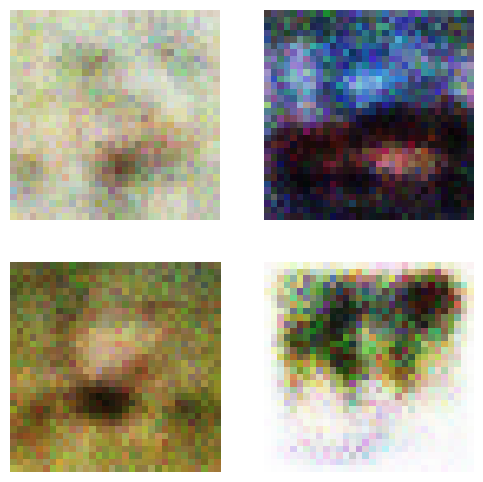

In [ ]:
# Section 4: Execute Training and Visualization
if __name__ == "__main__":
    generator, device = train_gan_with_clustering(epochs=50) # Get generator and device from train_gan_with_clustering
